In [ ]:
# Install kaggle library
!pip install -q kaggle

# Move the uploaded kaggle.json to the correct directory and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the ODIR-5K Classification dataset
!kaggle datasets download -d tanjemahamed/odir5k-classification

# Unzip the dataset quietly
!unzip -q odir5k-classification.zip -d odir_dataset

print("Dataset downloaded and extracted successfully!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/tanjemahamed/odir5k-classification
License(s): other
100% 374M/374M [00:04<00:00, 94.1MB/s]

Dataset downloaded and extracted successfully!


--- ODIR-5K Statistics ---
Class 'ageDegeneration': 266 images
Class 'cataract': 293 images
Class 'diabetes': 1608 images
Class 'glaucoma': 284 images
Class 'hypertension': 128 images
Class 'myopia': 232 images
Class 'normal': 2873 images
Class 'others': 708 images


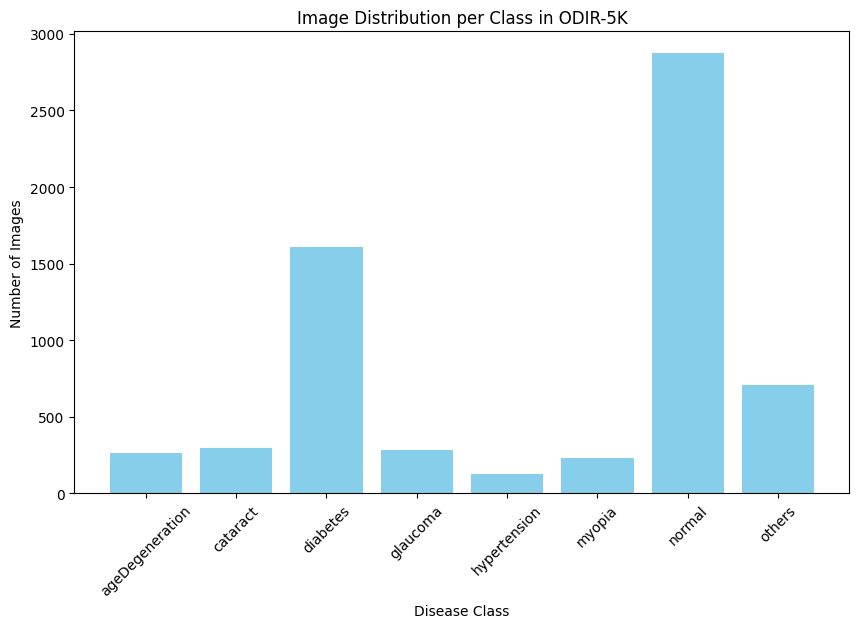

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Path to the extracted dataset
data_dir = 'odir_dataset/datasets'
classes = sorted(os.listdir(data_dir))


class_counts = {}
for cls in classes:
    class_path = os.path.join(data_dir, cls)
    if os.path.isdir(class_path):
        class_counts[cls] = len(os.listdir(class_path))

# Display the statistics
print("--- ODIR-5K Statistics ---")
for cls, count in class_counts.items():
    print(f"Class '{cls}': {count} images")

plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title('Image Distribution per Class in ODIR-5K')
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()


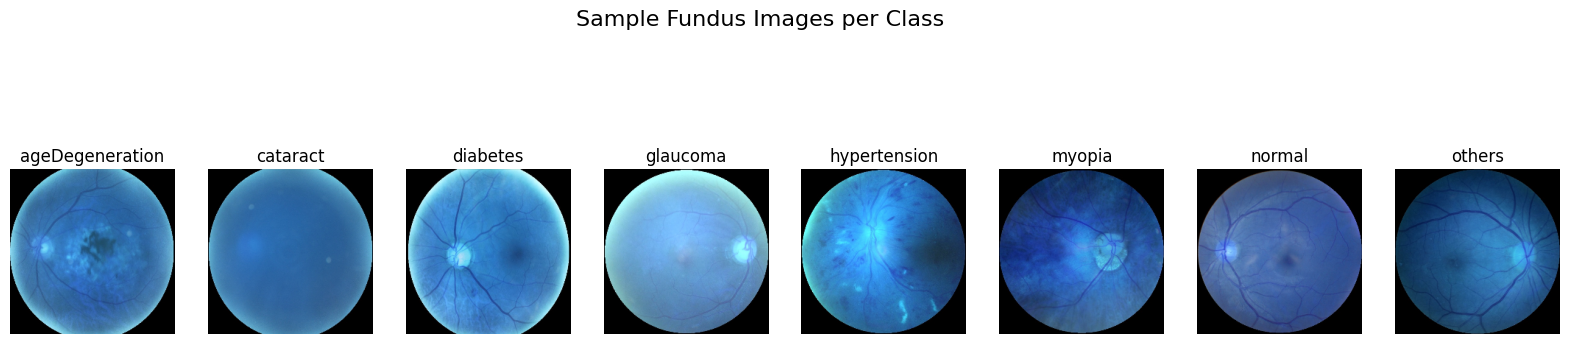

In [ ]:

fig, axes = plt.subplots(1, len(classes), figsize=(20, 5))
for idx, cls in enumerate(classes):
    class_path = os.path.join(data_dir, cls)
    # Get the first image in the directory
    sample_img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_img_name)

    # Read and convert BGR to RGB for accurate matplotlib display
    img = cv2.imread(img_path)
    # img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(img_rgb)
    axes[idx].set_title(cls)
    axes[idx].axis('off')
plt.suptitle("Sample Fundus Images per Class", fontsize=16)
plt.show()

In [ ]:
# Download the ARMD Curated Dataset 2023
!kaggle datasets download -d rakhshandamujib/armd-curated-dataset-2023

# Unzip the dataset quietly into a new folder
!unzip -q armd-curated-dataset-2023.zip -d armd_dataset

print("ARMD Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/rakhshandamujib/armd-curated-dataset-2023
License(s): unknown
100% 42.7M/42.7M [00:00<00:00, 49.8MB/s]

ARMD Dataset downloaded and extracted successfully!


Total ARMD images found: 511

--- Image Sources Breakdown ---
RFMiD: 144 images
ODIR-2019: 280 images
1kIM: 65 images
ARIA: 22 images


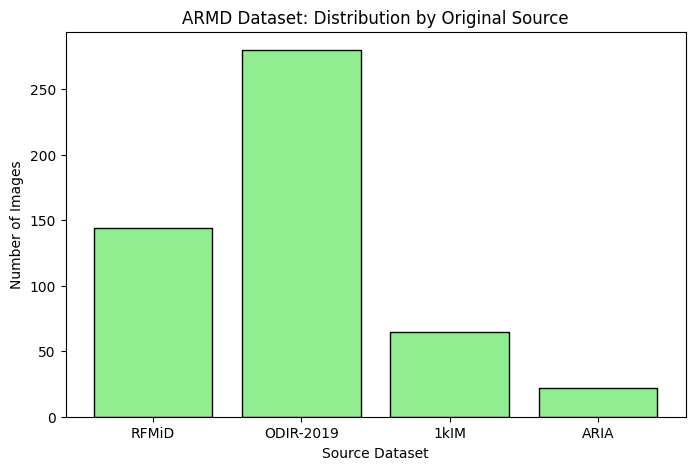

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import cv2
from collections import Counter

# Path to the ARMD images folder
armd_dir = 'armd_dataset/All ARMD images'
image_paths = glob.glob(os.path.join(armd_dir, '*.png'))

print(f"Total ARMD images found: {len(image_paths)}\n")

sources = []
for path in image_paths:
    filename = os.path.basename(path)
    # Checking for the specific substrings
    if '1kIM' in filename:
        sources.append('1kIM')
    elif 'RFiMD' in filename or 'RFMiD' in filename: # Account for potential typos in filenames
        sources.append('RFMiD')
    elif 'ORID19' in filename or 'ODIR' in filename:
        sources.append('ODIR-2019')
    elif 'aria' in filename.lower():
        sources.append('ARIA')
    else:
        sources.append('Other/Unknown')

source_counts = Counter(sources)

print("--- Image Sources Breakdown ---")
for source, count in source_counts.items():
    print(f"{source}: {count} images")

plt.figure(figsize=(8, 5))
plt.bar(source_counts.keys(), source_counts.values(), color='lightgreen', edgecolor='black')
plt.title('ARMD Dataset: Distribution by Original Source')
plt.xlabel('Source Dataset')
plt.ylabel('Number of Images')
plt.show()



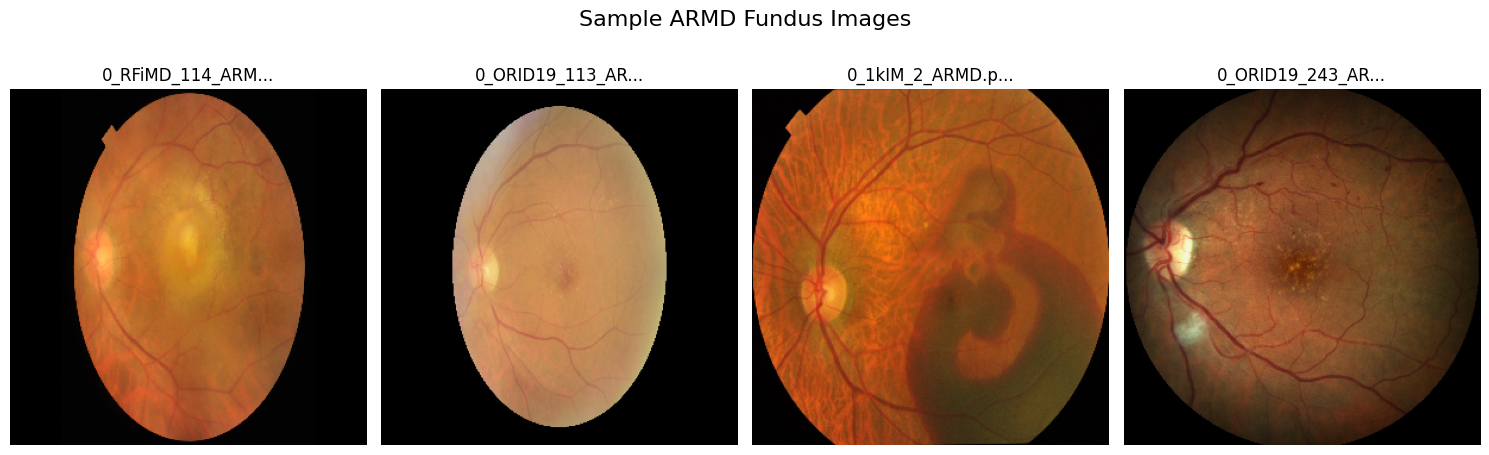

In [ ]:
num_samples = 4
fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
for i in range(num_samples):
    if i < len(image_paths):
        img_path = image_paths[i]
        # Read and convert BGR to RGB for matplotlib
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img_rgb)
        # Show a shortened version of the filename as the title
        axes[i].set_title(os.path.basename(img_path)[:15] + "...")
        axes[i].axis('off')

plt.suptitle("Sample ARMD Fundus Images", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Download the Eye Disease Image Dataset - Mendeley
!kaggle datasets download -d linabennaa/eye-disease-image-dataset-mendeley

# Unzip the dataset quietly into a new folder
!unzip -q eye-disease-image-dataset-mendeley.zip -d mendeley_dataset

print("Mendeley Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/linabennaa/eye-disease-image-dataset-mendeley
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.13G/2.13G [00:34<00:00, 66.8MB/s]

Mendeley Dataset downloaded and extracted successfully!


--- Mendeley Augmented Dataset Statistics ---
Class 'Central Serous Chorioretinopathy_Color Fundus': 606 images
Class 'Diabetic Retinopathy': 3444 images
Class 'Disc Edema': 762 images
Class 'Glaucoma': 2880 images
Class 'Healthy': 2676 images
Class 'Macular Scar': 1937 images
Class 'Myopia': 2251 images
Class 'Pterygium': 102 images
Class 'Retinal Detachment': 750 images
Class 'Retinitis Pigmentosa': 834 images

Total Images: 16242


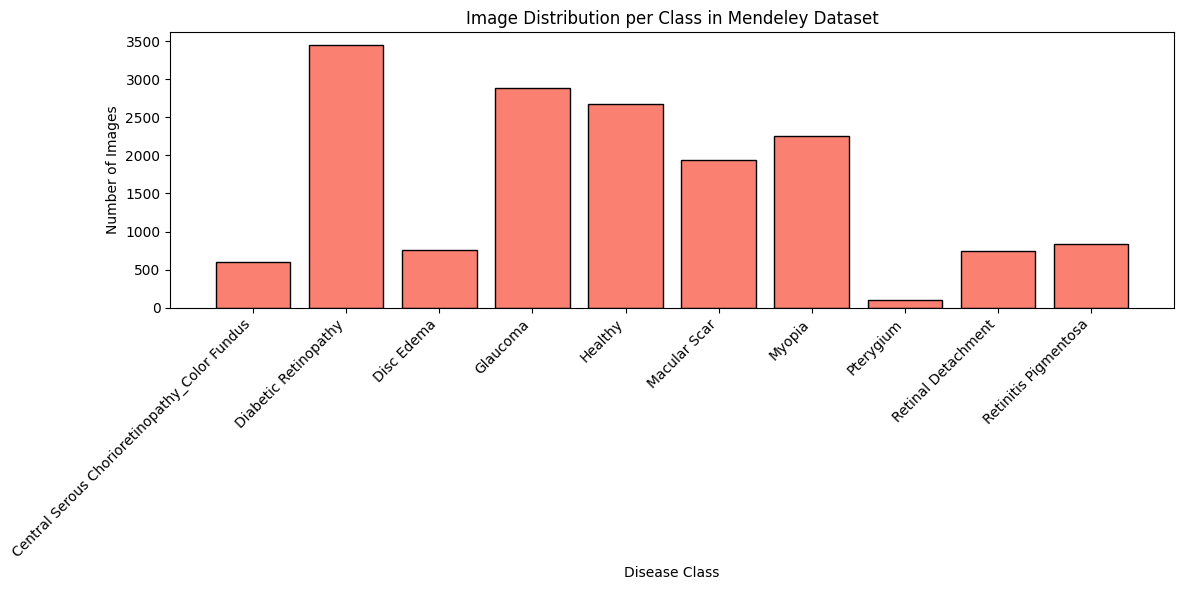

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Path to the Augmented Dataset folder
mendeley_dir = 'mendeley_dataset/Augmented Dataset'
mendeley_classes = [d for d in os.listdir(mendeley_dir) if os.path.isdir(os.path.join(mendeley_dir, d))]
mendeley_classes.sort()


mendeley_counts = {}
total_images = 0

print("--- Mendeley Augmented Dataset Statistics ---")
for cls in mendeley_classes:
    class_path = os.path.join(mendeley_dir, cls)
    count = len(os.listdir(class_path))
    mendeley_counts[cls] = count
    total_images += count
    print(f"Class '{cls}': {count} images")

print(f"\nTotal Images: {total_images}")

plt.figure(figsize=(12, 6))
plt.bar(mendeley_counts.keys(), mendeley_counts.values(), color='salmon', edgecolor='black')
plt.title('Image Distribution per Class in Mendeley Dataset')
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


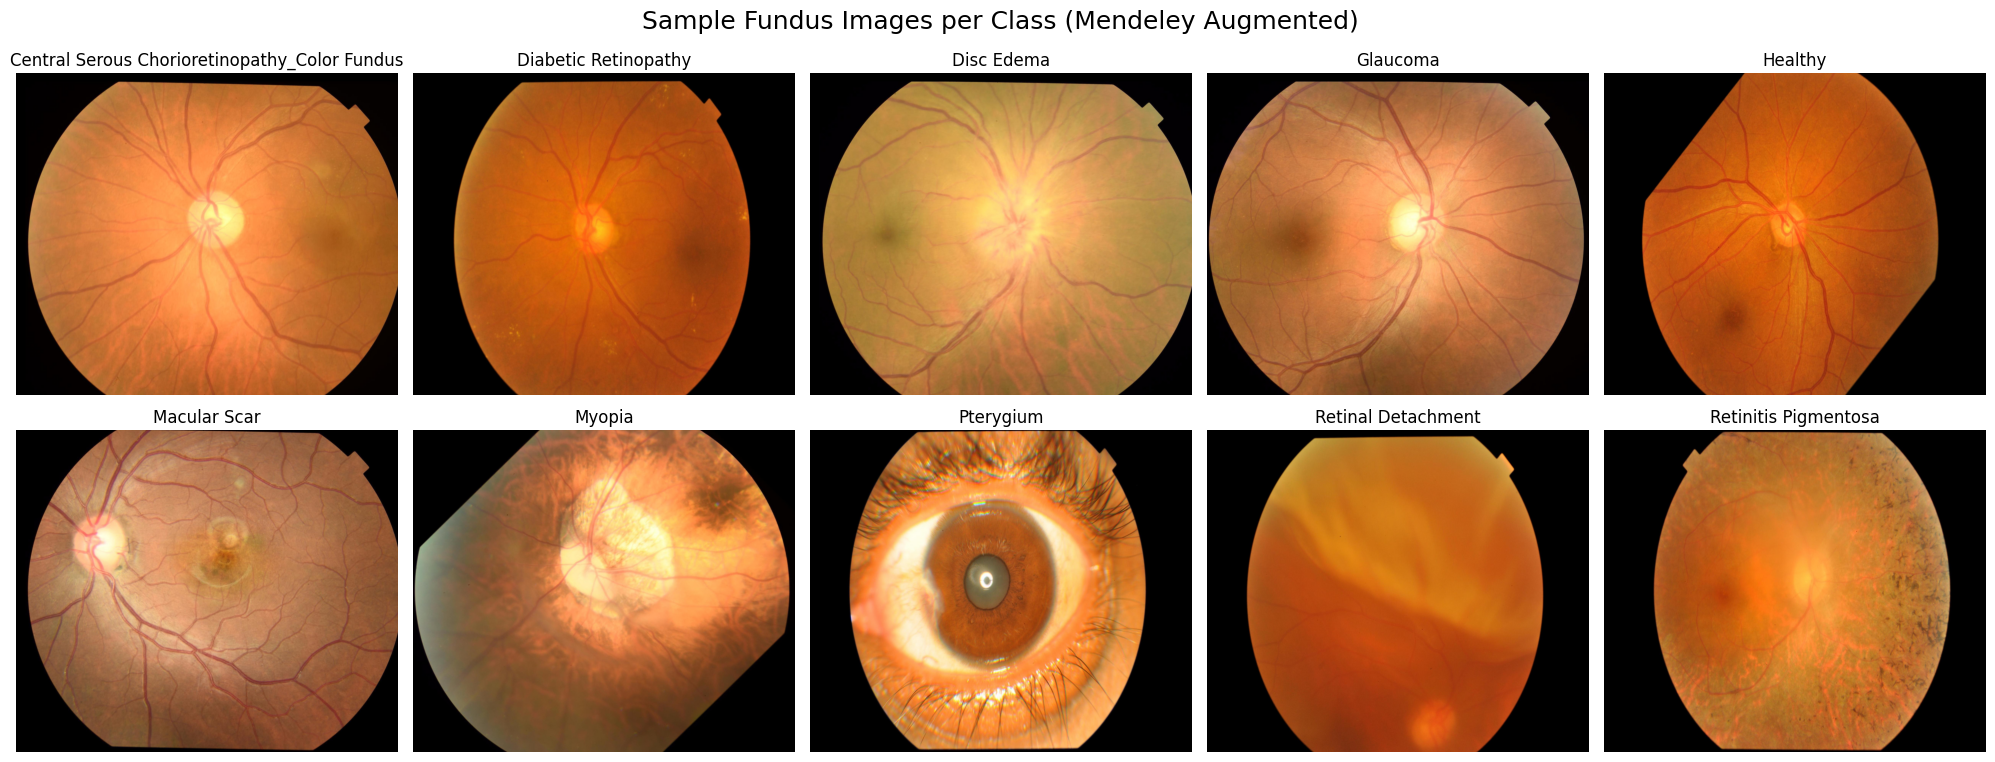

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, cls in enumerate(mendeley_classes):
    class_path = os.path.join(mendeley_dir, cls)
    # Safely get the first image
    images_in_class = os.listdir(class_path)
    if images_in_class:
        sample_img_name = images_in_class[0]
        img_path = os.path.join(class_path, sample_img_name)

        # Read and convert BGR to RGB
        img = cv2.imread(img_path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img_rgb)
            axes[idx].set_title(cls)
            axes[idx].axis('off')

plt.suptitle("Sample Fundus Images per Class (Mendeley Augmented)", fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
# Download the Eye Diseases Classification Dataset
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification

# Unzip the dataset quietly into a new folder
!unzip -q eye-diseases-classification.zip -d eye_diseases_4

print("Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:10<00:00, 75.6MB/s]

Dataset downloaded and extracted successfully!


--- Eye Diseases Classification (Dataset 4) Statistics ---
Class 'cataract': 1038 images
Class 'diabetic_retinopathy': 1098 images
Class 'glaucoma': 1007 images
Class 'normal': 1074 images


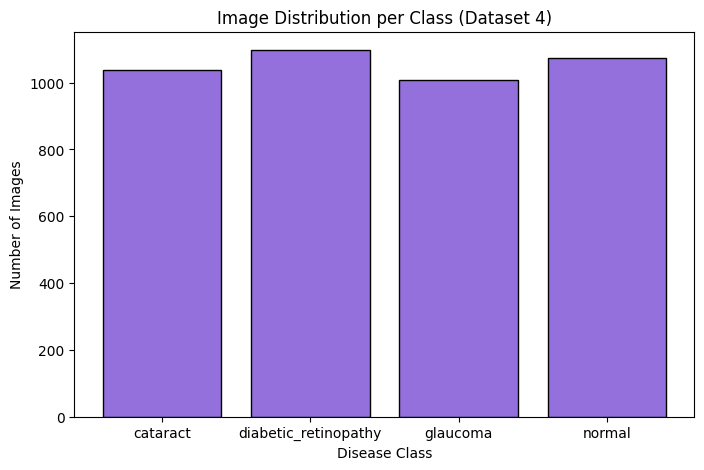

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

dataset4_dir = 'eye_diseases_4/dataset'
classes_4 = [d for d in os.listdir(dataset4_dir) if os.path.isdir(os.path.join(dataset4_dir, d))]
classes_4.sort()

counts_4 = {}
for cls in classes_4:
    class_path = os.path.join(dataset4_dir, cls)
    counts_4[cls] = len(os.listdir(class_path))

print("--- Eye Diseases Classification (Dataset 4) Statistics ---")
for cls, count in counts_4.items():
    print(f"Class '{cls}': {count} images")

plt.figure(figsize=(8, 5))
plt.bar(counts_4.keys(), counts_4.values(), color='mediumpurple', edgecolor='black')
plt.title('Image Distribution per Class (Dataset 4)')
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.show()


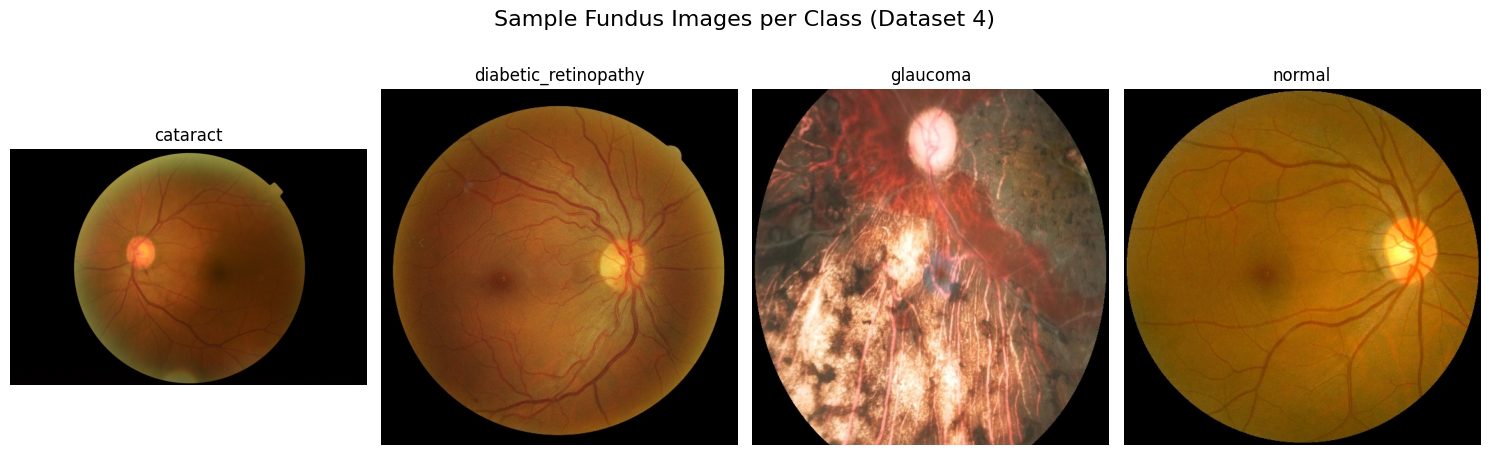

In [ ]:

fig, axes = plt.subplots(1, len(classes_4), figsize=(15, 5))

for idx, cls in enumerate(classes_4):
    class_path = os.path.join(dataset4_dir, cls)
    images_in_class = os.listdir(class_path)

    if images_in_class:
        sample_img_name = images_in_class[0]
        img_path = os.path.join(class_path, sample_img_name)

        # Read and convert BGR to RGB
        img = cv2.imread(img_path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img_rgb)
            axes[idx].set_title(cls)
            axes[idx].axis('off')

plt.suptitle("Sample Fundus Images per Class (Dataset 4)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Download the Hypertension Dataset
!kaggle datasets download -d harshwardhanfartale/hypertension-and-hypertensive-retinopathy-dataset

# Unzip quietly
!unzip -q hypertension-and-hypertensive-retinopathy-dataset.zip -d hypertension_dataset

print("Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/harshwardhanfartale/hypertension-and-hypertensive-retinopathy-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 1.00G/1.00G [00:16<00:00, 63.6MB/s]

Dataset downloaded and extracted successfully!


--- Hypertension Dataset Statistics ---
Hypertensive
0    356
1    356
Name: count, dtype: int64


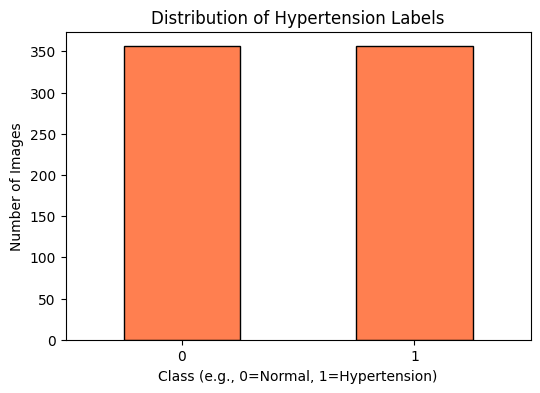

/tmp/ipykernel_30317/1153287376.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_labels[df_labels[label_col] == class_counts.index[0]].iloc[0][0], # First image of class A
/tmp/ipykernel_30317/1153287376.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_labels[df_labels[label_col] == class_counts.index[1]].iloc[0][0]  # First image of class B


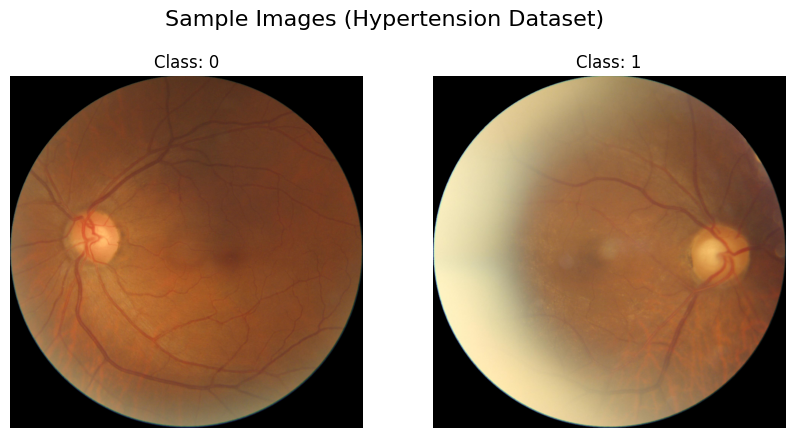

In [ ]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt


base_path = 'hypertension_dataset/1-Hypertensive Classification/1-Hypertensive Classification'
images_dir = os.path.join(base_path, '1-Images/1-Training Set')
csv_path = os.path.join(base_path, '2-Groundtruths/HRDC Hypertensive Classification Training Labels.csv')


try:
    df_labels = pd.read_csv(csv_path)
    print("--- Hypertension Dataset Statistics ---")


    label_col = df_labels.columns[1]
    class_counts = df_labels[label_col].value_counts()
    print(class_counts)


    plt.figure(figsize=(6, 4))
    class_counts.plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Distribution of Hypertension Labels')
    plt.xlabel('Class (e.g., 0=Normal, 1=Hypertension)')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=0)
    plt.show()


    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    sample_images = [
        df_labels[df_labels[label_col] == class_counts.index[0]].iloc[0][0], # First image of class A
        df_labels[df_labels[label_col] == class_counts.index[1]].iloc[0][0]  # First image of class B
    ]

    for idx, img_name in enumerate(sample_images):
        if not img_name.endswith('.png') and not img_name.endswith('.jpg'):
            img_name += '.png'

        img_path = os.path.join(images_dir, img_name)
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img_rgb)
            axes[idx].set_title(f"Class: {class_counts.index[idx]}")
            axes[idx].axis('off')
    plt.suptitle("Sample Images (Hypertension Dataset)", fontsize=16)
    plt.show()

except Exception as e:
    print(f"Could not load CSV automatically. Please verify the CSV filename in the folder: {e}")

Mounted at /content/drive

Starting to merge datasets

--- FINAL UNIFIED DATASET STATISTICS ---
ARMD: 777 images
Cataract: 1331 images
Diabetic_Retinopathy: 6150 images
Glaucoma: 4171 images
Hypertensive_Retinopathy: 484 images
Myopia: 2483 images
Normal: 6979 images


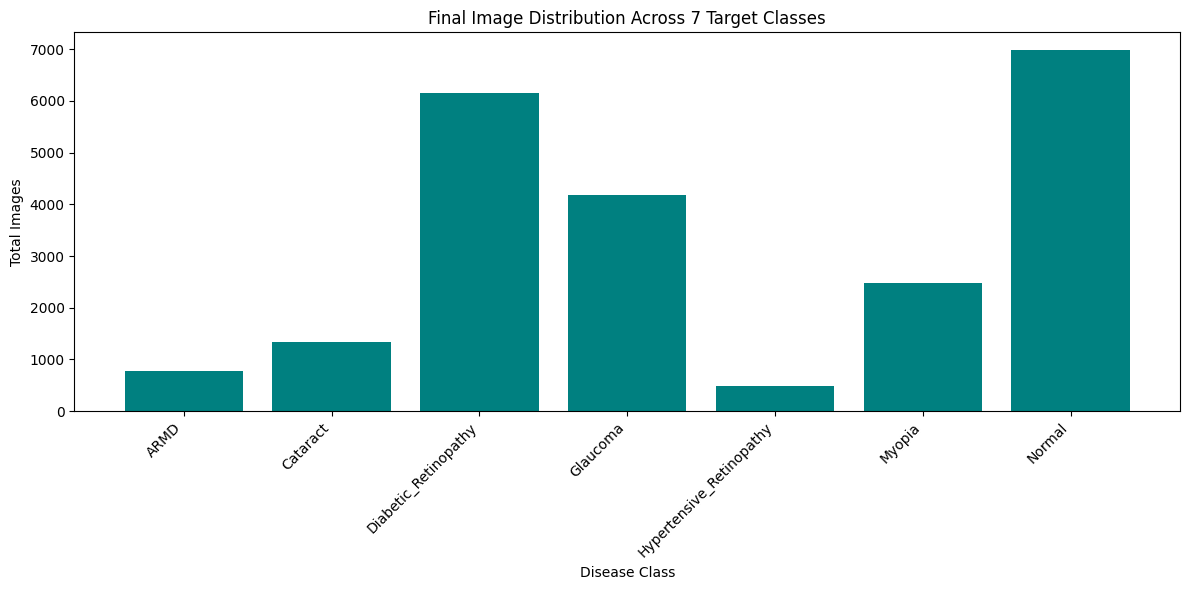


Zipping the unified dataset... (This will take some time)
Transferring to Google Drive at: /content/drive/MyDrive/Unified_Ophthalmology_Dataset.zip
SUCCESS! Data is merged and saved to your Drive.


In [ ]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

#  Mount Google Drive for the final export
drive.mount('/content/drive')

#  Download and extract the remaining 4 datasets
print("Downloading remaining datasets...")

#  Create the Unified Directory Structure
unified_dir = 'Unified_Ophthalmology_Dataset'
target_classes = [
    'ARMD',
    'Cataract',
    'Diabetic_Retinopathy',
    'Glaucoma',
    'Hypertensive_Retinopathy',
    'Myopia',
    'Normal'
]

for cls in target_classes:
    os.makedirs(os.path.join(unified_dir, cls), exist_ok=True)

#  Helper function to copy images
def copy_images(source_dir, destination_dir):
    if not os.path.exists(source_dir):
        print(f"Warning: Source not found -> {source_dir}")
        return
    count = 0
    for file in os.listdir(source_dir):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            shutil.copy(os.path.join(source_dir, file), destination_dir)
            count += 1
    return count

print("\nStarting to merge datasets")

# --- Routing Dataset 1 (ODIR-5K) ---
copy_images('odir_dataset/datasets/ageDegeneration', f'{unified_dir}/ARMD')
copy_images('odir_dataset/datasets/cataract', f'{unified_dir}/Cataract')
copy_images('odir_dataset/datasets/diabetes', f'{unified_dir}/Diabetic_Retinopathy')
copy_images('odir_dataset/datasets/glaucoma', f'{unified_dir}/Glaucoma')
copy_images('odir_dataset/datasets/hypertension', f'{unified_dir}/Hypertensive_Retinopathy')
copy_images('odir_dataset/datasets/myopia', f'{unified_dir}/Myopia')
copy_images('odir_dataset/datasets/normal', f'{unified_dir}/Normal')

# --- Routing Dataset 2 (ARMD Curated) ---
copy_images('armd_dataset/All ARMD images', f'{unified_dir}/ARMD')

# --- Routing Dataset 3 (Mendeley Augmented) ---
copy_images('mendeley_dataset/Augmented Dataset/Diabetic Retinopathy', f'{unified_dir}/Diabetic_Retinopathy')
copy_images('mendeley_dataset/Augmented Dataset/Glaucoma', f'{unified_dir}/Glaucoma')
copy_images('mendeley_dataset/Augmented Dataset/Myopia', f'{unified_dir}/Myopia')
copy_images('mendeley_dataset/Augmented Dataset/Healthy', f'{unified_dir}/Normal')

# --- Routing Dataset 4 (Eye Diseases Classification) ---
copy_images('eye_diseases_4/dataset/cataract', f'{unified_dir}/Cataract')
copy_images('eye_diseases_4/dataset/diabetic_retinopathy', f'{unified_dir}/Diabetic_Retinopathy')
copy_images('eye_diseases_4/dataset/glaucoma', f'{unified_dir}/Glaucoma')
copy_images('eye_diseases_4/dataset/normal', f'{unified_dir}/Normal')

# --- Routing Dataset 5 (Hypertension Dataset) ---
hyper_base = 'hypertension_dataset/1-Hypertensive Classification/1-Hypertensive Classification'
hyper_images = os.path.join(hyper_base, '1-Images/1-Training Set')
hyper_csv = os.path.join(hyper_base, '2-Groundtruths/HRDC Hypertensive Classification Training Labels.csv')

if os.path.exists(hyper_csv):
    df_hyper = pd.read_csv(hyper_csv)
    img_col = df_hyper.columns[0]
    label_col = df_hyper.columns[1]

    for index, row in df_hyper.iterrows():
        img_name = str(row[img_col])
        if not img_name.endswith('.png') and not img_name.endswith('.jpg'):
            img_name += '.png'

        src_path = os.path.join(hyper_images, img_name)
        if os.path.exists(src_path):
            if row[label_col] == 1:
                shutil.copy(src_path, f'{unified_dir}/Hypertensive_Retinopathy')
            else:
                shutil.copy(src_path, f'{unified_dir}/Normal')


#  Final Statistics & Visualization
final_counts = {}
for cls in target_classes:
    final_counts[cls] = len(os.listdir(os.path.join(unified_dir, cls)))

print("\n--- FINAL UNIFIED DATASET STATISTICS ---")
for cls, count in final_counts.items():
    print(f"{cls}: {count} images")

plt.figure(figsize=(12, 6))
plt.bar(final_counts.keys(), final_counts.values(), color='teal')
plt.title('Final Image Distribution Across 7 Target Classes')
plt.xlabel('Disease Class')
plt.ylabel('Total Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#  Zip and Export to Google Drive
print("\nZipping the unified dataset... (This will take some time)")
shutil.make_archive('Unified_Ophthalmology_Dataset', 'zip', unified_dir)

drive_destination = '/content/drive/MyDrive/Unified_Ophthalmology_Dataset.zip'
print(f"Transferring to Google Drive at: {drive_destination}")
shutil.copy('Unified_Ophthalmology_Dataset.zip', drive_destination)

print("SUCCESS! Data is merged and saved to your Drive.")

In [ ]:
import zipfile
from collections import Counter

# حدد الـ path
ZIP_PATH = 'Unified_Ophthalmology_Dataset.zip'

# افتح الـ zip مباشرة من غير ما تفكه
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    files = [f for f in z.namelist() if not f.endswith('/')]

# عدّ الصور لكل class
classes = Counter()
for f in files:
    parts = f.split('/')
    if len(parts) >= 2:
        classes[parts[-2]] += 1

print("--- محتوى الـ ZIP ---")
for cls, count in sorted(classes.items()):
    print(f"{cls}: {count} images")
print(f"\nTotal: {sum(classes.values())} images")

# شوف لو في أسماء متكررة
filenames = [f.split('/')[-1] for f in files]
dupes = {k: v for k, v in Counter(filenames).items() if v > 1}
print(f"\nأسماء متكررة: {len(dupes)}")
if dupes:
    for name, count in list(dupes.items())[:5]:
        print(f"  {name}: تكرر {count} مرات")

FileNotFoundError: [Errno 2] No such file or directory: 'Unified_Ophthalmology_Dataset.zip'